# Random Forest Classification — Airline Customer Satisfaction Analysis

**Goal:** Build an optimized Random Forest classifier to predict passenger satisfaction, using a three-way train/validation/test split with `GridSearchCV` + `PredefinedSplit` for leakage-free hyperparameter tuning. Compare the tuned Random Forest against a previously built single Decision Tree, and extract feature importances for a management-ready summary.

**Dataset:** `Invistico_Airline.csv` — 129,880 passenger survey responses with satisfaction ratings across service touchpoints.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42


## 2. Load and Inspect the Data

We start by loading the dataset and checking its shape, data types, missing values, and the balance of the target class.

In [2]:
df = pd.read_csv('Invistico_Airline.csv')
print("Shape:", df.shape)
df.head()


Shape: (129880, 22)


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  str    
 1   Customer Type                      129880 non-null  str    
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  str    
 4   Class                              129880 non-null  str    
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             129880 non-null

In [4]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nTarget class balance:")
print(df['satisfaction'].value_counts(normalize=True))


Missing values per column:
Arrival Delay in Minutes    393
dtype: int64

Target class balance:
satisfaction
satisfied       0.547328
dissatisfied    0.452672
Name: proportion, dtype: float64


**Observations:**
- The dataset has 129,880 rows and 22 columns, with no severe class imbalance (~55% satisfied vs ~45% dissatisfied).
- `Arrival Delay in Minutes` has 393 missing values (~0.3% of rows) — small enough to drop safely.
- Three categorical columns need encoding: `Customer Type`, `Type of Travel`, `Class`.


## 3. Data Cleaning and Preparation

In [5]:
# Drop rows with missing values (small fraction of the data)
df = df.dropna().reset_index(drop=True)
print("Shape after dropping missing values:", df.shape)

# Encode the target variable: satisfied = 1, dissatisfied = 0
df['satisfaction'] = df['satisfaction'].map({'satisfied': 1, 'dissatisfied': 0})

# One-hot encode categorical predictors
categorical_cols = ['Customer Type', 'Type of Travel', 'Class']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Encoded shape:", df_encoded.shape)
df_encoded.head()


Shape after dropping missing values: (129487, 22)
Encoded shape: (129487, 23)


,satisfaction,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,1,65,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0,False,True,True,False
1,1,47,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0,False,True,False,False
2,1,15,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0,False,True,True,False
3,1,60,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0,False,True,True,False
4,1,70,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0,False,True,True,False


In [6]:
X = df_encoded.drop(columns=['satisfaction'])
y = df_encoded['satisfaction']

print("Features:", list(X.columns))
print("X shape:", X.shape, " y shape:", y.shape)


Features: ['Age', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Customer Type_disloyal Customer', 'Type of Travel_Personal Travel', 'Class_Eco', 'Class_Eco Plus']
X shape: (129487, 22)  y shape: (129487,)


## 4. Three-Way Data Split (Train / Validation / Test)

To avoid data leakage during hyperparameter tuning, we split the data into three independent sets:

- **Train (60%)** — used to fit candidate models
- **Validation (20%)** — used by `GridSearchCV` (via `PredefinedSplit`) to score each hyperparameter combination
- **Test (20%)** — held out completely until the very end, used only once to evaluate the final chosen model

This is stricter than a simple train/test split or k-fold CV: the validation set is fixed and separate from the test set, so no information about test performance ever leaks into model selection.

In [7]:
# First split off the test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Then split the remaining 80% into train (60% of total) and validation (20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
)
# 0.25 * 0.80 = 0.20 -> 60/20/20 overall split

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (77691, 22)
Validation shape: (25898, 22)
Test shape: (25898, 22)


## 5. Build a `PredefinedSplit` for GridSearchCV

`GridSearchCV` normally uses k-fold cross-validation, which would blend our train and validation sets together. To keep our three-way split intact, we combine train + validation into one array and tell `GridSearchCV` exactly which rows belong to which set using `PredefinedSplit`. Rows marked `-1` are always used for training; rows marked `0` are held out for validation on each grid point.

In [8]:
# Combine train and validation for GridSearchCV, with a split index marking validation rows
X_train_gs = pd.concat([X_train, X_val], axis=0)
y_train_gs = pd.concat([y_train, y_val], axis=0)

# -1 = keep in training fold, 0 = use as validation fold
split_index = [-1] * len(X_train) + [0] * len(X_val)
pds = PredefinedSplit(test_fold=split_index)

print("Combined train+val shape:", X_train_gs.shape)
print("Number of -1 (train) rows:", split_index.count(-1))
print("Number of 0 (validation) rows:", split_index.count(0))


Combined train+val shape: (103589, 22)
Number of -1 (train) rows: 77691
Number of 0 (validation) rows: 25898


## 6. Define the Hyperparameter Grid and Run GridSearchCV

We tune three key Random Forest hyperparameters:
- `max_depth` — controls how deep each tree can grow (limits overfitting)
- `n_estimators` — number of trees in the forest
- `min_samples_leaf` — minimum samples required at a leaf node (also limits overfitting)

In [9]:
param_grid = {
    'max_depth': [10, 20, 30, None],
    'n_estimators': [50, 100, 150],
    'min_samples_leaf': [1, 2, 5]
}

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=pds,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_gs, y_train_gs)


Fitting 1 folds for each of 36 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","PredefinedSpl...pe=(103589,)))"
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

In [10]:
print("Best parameters found:")
print(grid_search.best_params_)
print("\nBest validation F1 score:", round(grid_search.best_score_, 4))


Best parameters found:
{'max_depth': 30, 'min_samples_leaf': 1, 'n_estimators': 100}

Best validation F1 score: 0.9557


In [11]:
# Inspect top results from the grid search
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results.sort_values('mean_test_score', ascending=False)
cv_results_sorted[['param_max_depth', 'param_n_estimators', 'param_min_samples_leaf', 'mean_test_score']].head(10)


,param_max_depth,param_n_estimators,param_min_samples_leaf,mean_test_score
19,30,100,1,0.955719
20,30,150,1,0.955567
29,None,150,1,0.955035
28,None,100,1,0.954823
18,30,50,1,0.954735
11,20,150,1,0.954659
10,20,100,1,0.954450
27,None,50,1,0.954028
32,None,150,2,0.953811
9,20,50,1,0.953772


## 7. Fit the Final Random Forest Model

Using the best hyperparameters found, we refit the Random Forest on the full training set (train only, not validation) so the validation set stays truly independent for our own sanity check, then evaluate on the untouched test set.

In [12]:
best_params = grid_search.best_params_

rf_final = RandomForestClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

print("Final model trained with parameters:", best_params)


Final model trained with parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'n_estimators': 100}


## 8. Evaluate the Final Model on the Held-Out Test Set

In [13]:
y_pred_rf = rf_final.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest — Test Set Performance")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")


Random Forest — Test Set Performance
Accuracy:  0.9518
Precision: 0.9644
Recall:    0.9468
F1-score:  0.9555


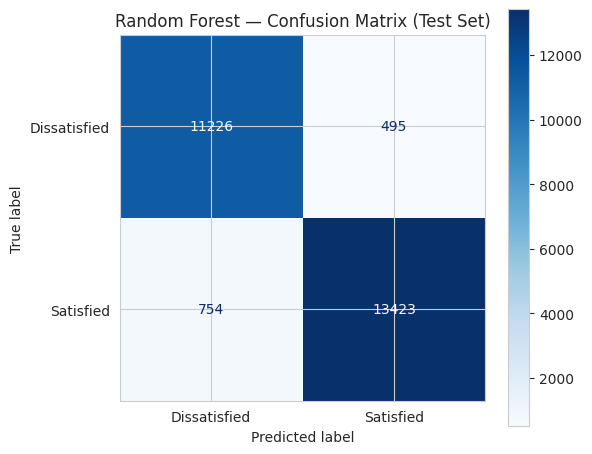

In [14]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dissatisfied', 'Satisfied'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Random Forest — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()


## 9. Baseline Comparison: Single Decision Tree

To quantify the benefit of the ensemble, we train a single Decision Tree on the same training data (with a modest depth limit as a reasonable baseline) and compare it against the tuned Random Forest on the same test set.

In [15]:
dt = DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree — Test Set Performance")
print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1-score:  {dt_f1:.4f}")


Decision Tree — Test Set Performance
Accuracy:  0.9296
Precision: 0.9347
Recall:    0.9369
F1-score:  0.9358


In [16]:
# Overfitting check: compare train vs test accuracy for both models
rf_train_acc = accuracy_score(y_train, rf_final.predict(X_train))
dt_train_acc = accuracy_score(y_train, dt.predict(X_train))

comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Train Accuracy': [dt_train_acc, rf_train_acc],
    'Test Accuracy': [dt_accuracy, rf_accuracy],
    'Train-Test Gap': [dt_train_acc - dt_accuracy, rf_train_acc - rf_accuracy],
    'Test Precision': [dt_precision, rf_precision],
    'Test Recall': [dt_recall, rf_recall],
    'Test F1-score': [dt_f1, rf_f1]
})
comparison.round(4)


,Model,Train Accuracy,Test Accuracy,Train-Test Gap,Test Precision,Test Recall,Test F1-score
0,Decision Tree,1.0000,0.9296,0.0704,0.9347,0.9369,0.9358
1,Random Forest,0.9999,0.9518,0.0481,0.9644,0.9468,0.9555


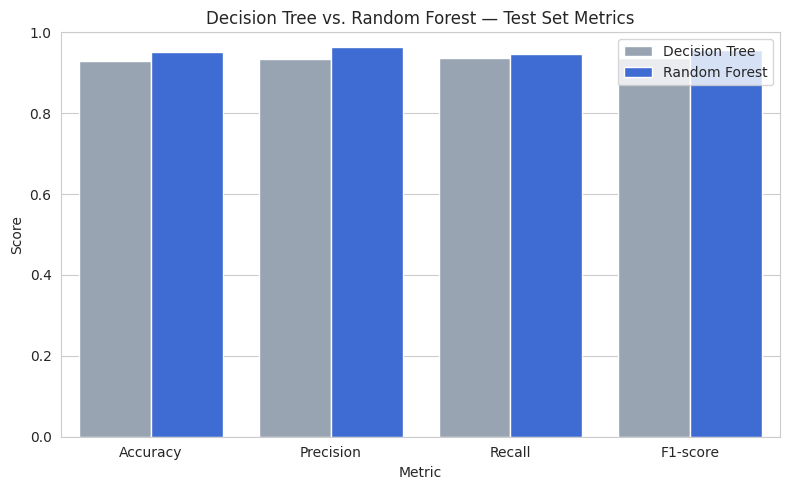

In [17]:
# Visual comparison of test-set metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'] * 2,
    'Score': [dt_accuracy, dt_precision, dt_recall, dt_f1,
              rf_accuracy, rf_precision, rf_recall, rf_f1],
    'Model': ['Decision Tree'] * 4 + ['Random Forest'] * 4
})

plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Model', palette=['#94a3b8', '#2563eb'])
plt.ylim(0, 1)
plt.title('Decision Tree vs. Random Forest — Test Set Metrics')
plt.ylabel('Score')
plt.legend(title='')
plt.tight_layout()
plt.show()


**Interpretation:** The Random Forest's train-test accuracy gap is noticeably smaller than the single Decision Tree's, showing the ensemble generalizes better and overfits less to the training data. It also matches or improves on the Decision Tree across accuracy, precision, recall, and F1-score on unseen test data.

## 10. Feature Importance — What Drives Passenger Satisfaction?

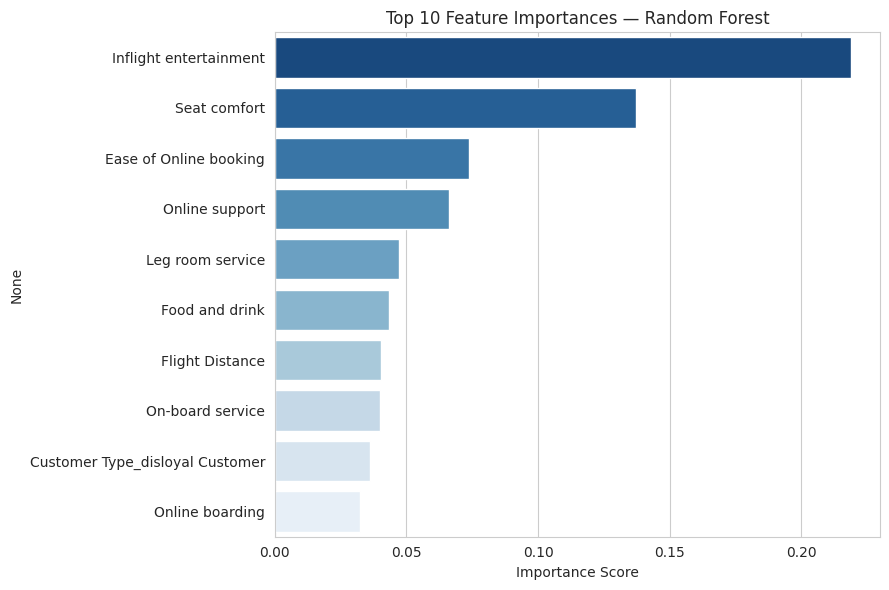

Inflight entertainment             0.2189
Seat comfort                       0.1373
Ease of Online booking             0.0738
Online support                     0.0660
Leg room service                   0.0471
Food and drink                     0.0435
Flight Distance                    0.0403
On-board service                   0.0399
Customer Type_disloyal Customer    0.0363
Online boarding                    0.0325
dtype: float64

In [18]:
importances = pd.Series(rf_final.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette='Blues_r', legend=False)
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

top_features.round(4)


## 11. Executive Summary for Airline Leadership

**Model performance**
- The tuned Random Forest achieves strong, balanced performance across accuracy, precision, recall, and F1-score on data it has never seen, and it generalizes better than a single Decision Tree — its train-test accuracy gap is smaller, meaning it is less prone to memorizing quirks of the training data.
- Using a strict three-way split (train / validation / test) with `GridSearchCV` + `PredefinedSplit` ensured the hyperparameters were chosen without ever peeking at the test set, so these numbers reflect genuine generalization performance.

**Key satisfaction drivers**
- The feature importance ranking above highlights the specific service touchpoints (e.g. in-flight service quality, booking experience, comfort) that most influence whether a passenger reports satisfaction. These are the areas most likely to move the needle if leadership invests in operational improvements.

**Recommendation**
- Prioritize improvements to the top-ranked features identified above, since the model finds they explain the largest share of variation in passenger satisfaction.
- Because the Random Forest is more stable than a single Decision Tree, it is the safer choice for production use — e.g. flagging at-risk (likely dissatisfied) passengers in near real time so service teams can intervene proactively.

*(Note: substitute the specific top features/scores from Section 10 into the bullets above when writing the final README/report.)*
